# Environment

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.chdir('/Users/burkelawlor/Repos/hci-xenium')

import anndata as ad
import spatialdata_plot

from utils.data_loading import *
from utils.spatial import *

# Load data

In [3]:
samples = [
    'LP1_LP2','LP3','LP4','LP5','LP6','LP7','LP8',
    # 'LPP1', 'LPP2', 'LPP3','LPP4',
    # 'ICI_LP1', 'ICI_LP2', 'ICI_LP3', 'ICI_LP4',
    # 'OLP1', 'OLP2', 'OLP3', 'OLP4', 'OLP5', 'OLP6'
    # 'NS1','NS2','NS3','NS4',
]

In [4]:
adata_lp = ad.read_h5ad("./data/processed/adata/lp+yale_2_annotated.h5ad")
adata = adata_lp[adata_lp.obs['ct_general'] != 'Unknown/low count'].copy()

/Users/burkelawlor/Repos/hci-xenium/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [5]:
# Load data and add annotations
sdata_dict = {}

for sample_name in samples:
    print(sample_name)
    print(xenium_paths[sample_name])

    sdata = load_sdata_from_xenium(sample_name, merge_adata=adata_lp, add_he_image=False)
    
    
    if sample_name == 'LP1_LP2':
    
        sdata_dict['LP1'] = sdata.query.bounding_box(
            axes=["x", "y"],
            min_coordinate=[0, 0],
            max_coordinate=[21500, 29000],
            target_coordinate_system="global",
        )

        sdata_dict['LP2'] = sdata.query.bounding_box(
            axes=["x", "y"],
            min_coordinate=[21500, 0],
            max_coordinate=[25717.0, 29000],
            target_coordinate_system="global",
        )

    else:
        sdata_dict[sample_name] = sdata

    print()
    print('-'*100)

    break

LP1_LP2
data/raw/Xenium/20260506__195908__28200/output-XETG00516__0076414__Region_4__20260506__200316


/opt/homebrew/Cellar/python@3.12/3.12.12_1/Frameworks/Python.framework/Versions/3.12/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


WARNING  The `feature_key` column feature_name is categorical with unknown categories. Please ensure the categories
         are known before calling `PointsModel.parse()` to avoid significant performance implications due to the   
         need for dask to compute the categories. If you did not use PointsModel.parse() explicitly in your code   
         (e.g. this message is coming from a reader in `spatialdata_io`), please report this finding.              


/opt/homebrew/Cellar/python@3.12/3.12.12_1/Frameworks/Python.framework/Versions/3.12/lib/python3.12/functools.py:912: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)
/opt/homebrew/Cellar/python@3.12/3.12.12_1/Frameworks/Python.framework/Versions/3.12/lib/python3.12/functools.py:912: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)



----------------------------------------------------------------------------------------------------


# Spatial plots of general cell types

/Users/burkelawlor/Repos/hci-xenium/.venv/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/Users/burkelawlor/Repos/hci-xenium/.venv/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/Users/burkelawlor/Repos/hci-xenium/.venv/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/Users/burkelawlor/Repos/hci-xenium/.venv/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/Users/burkelawlor/Repos/hci-xenium/.venv/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning

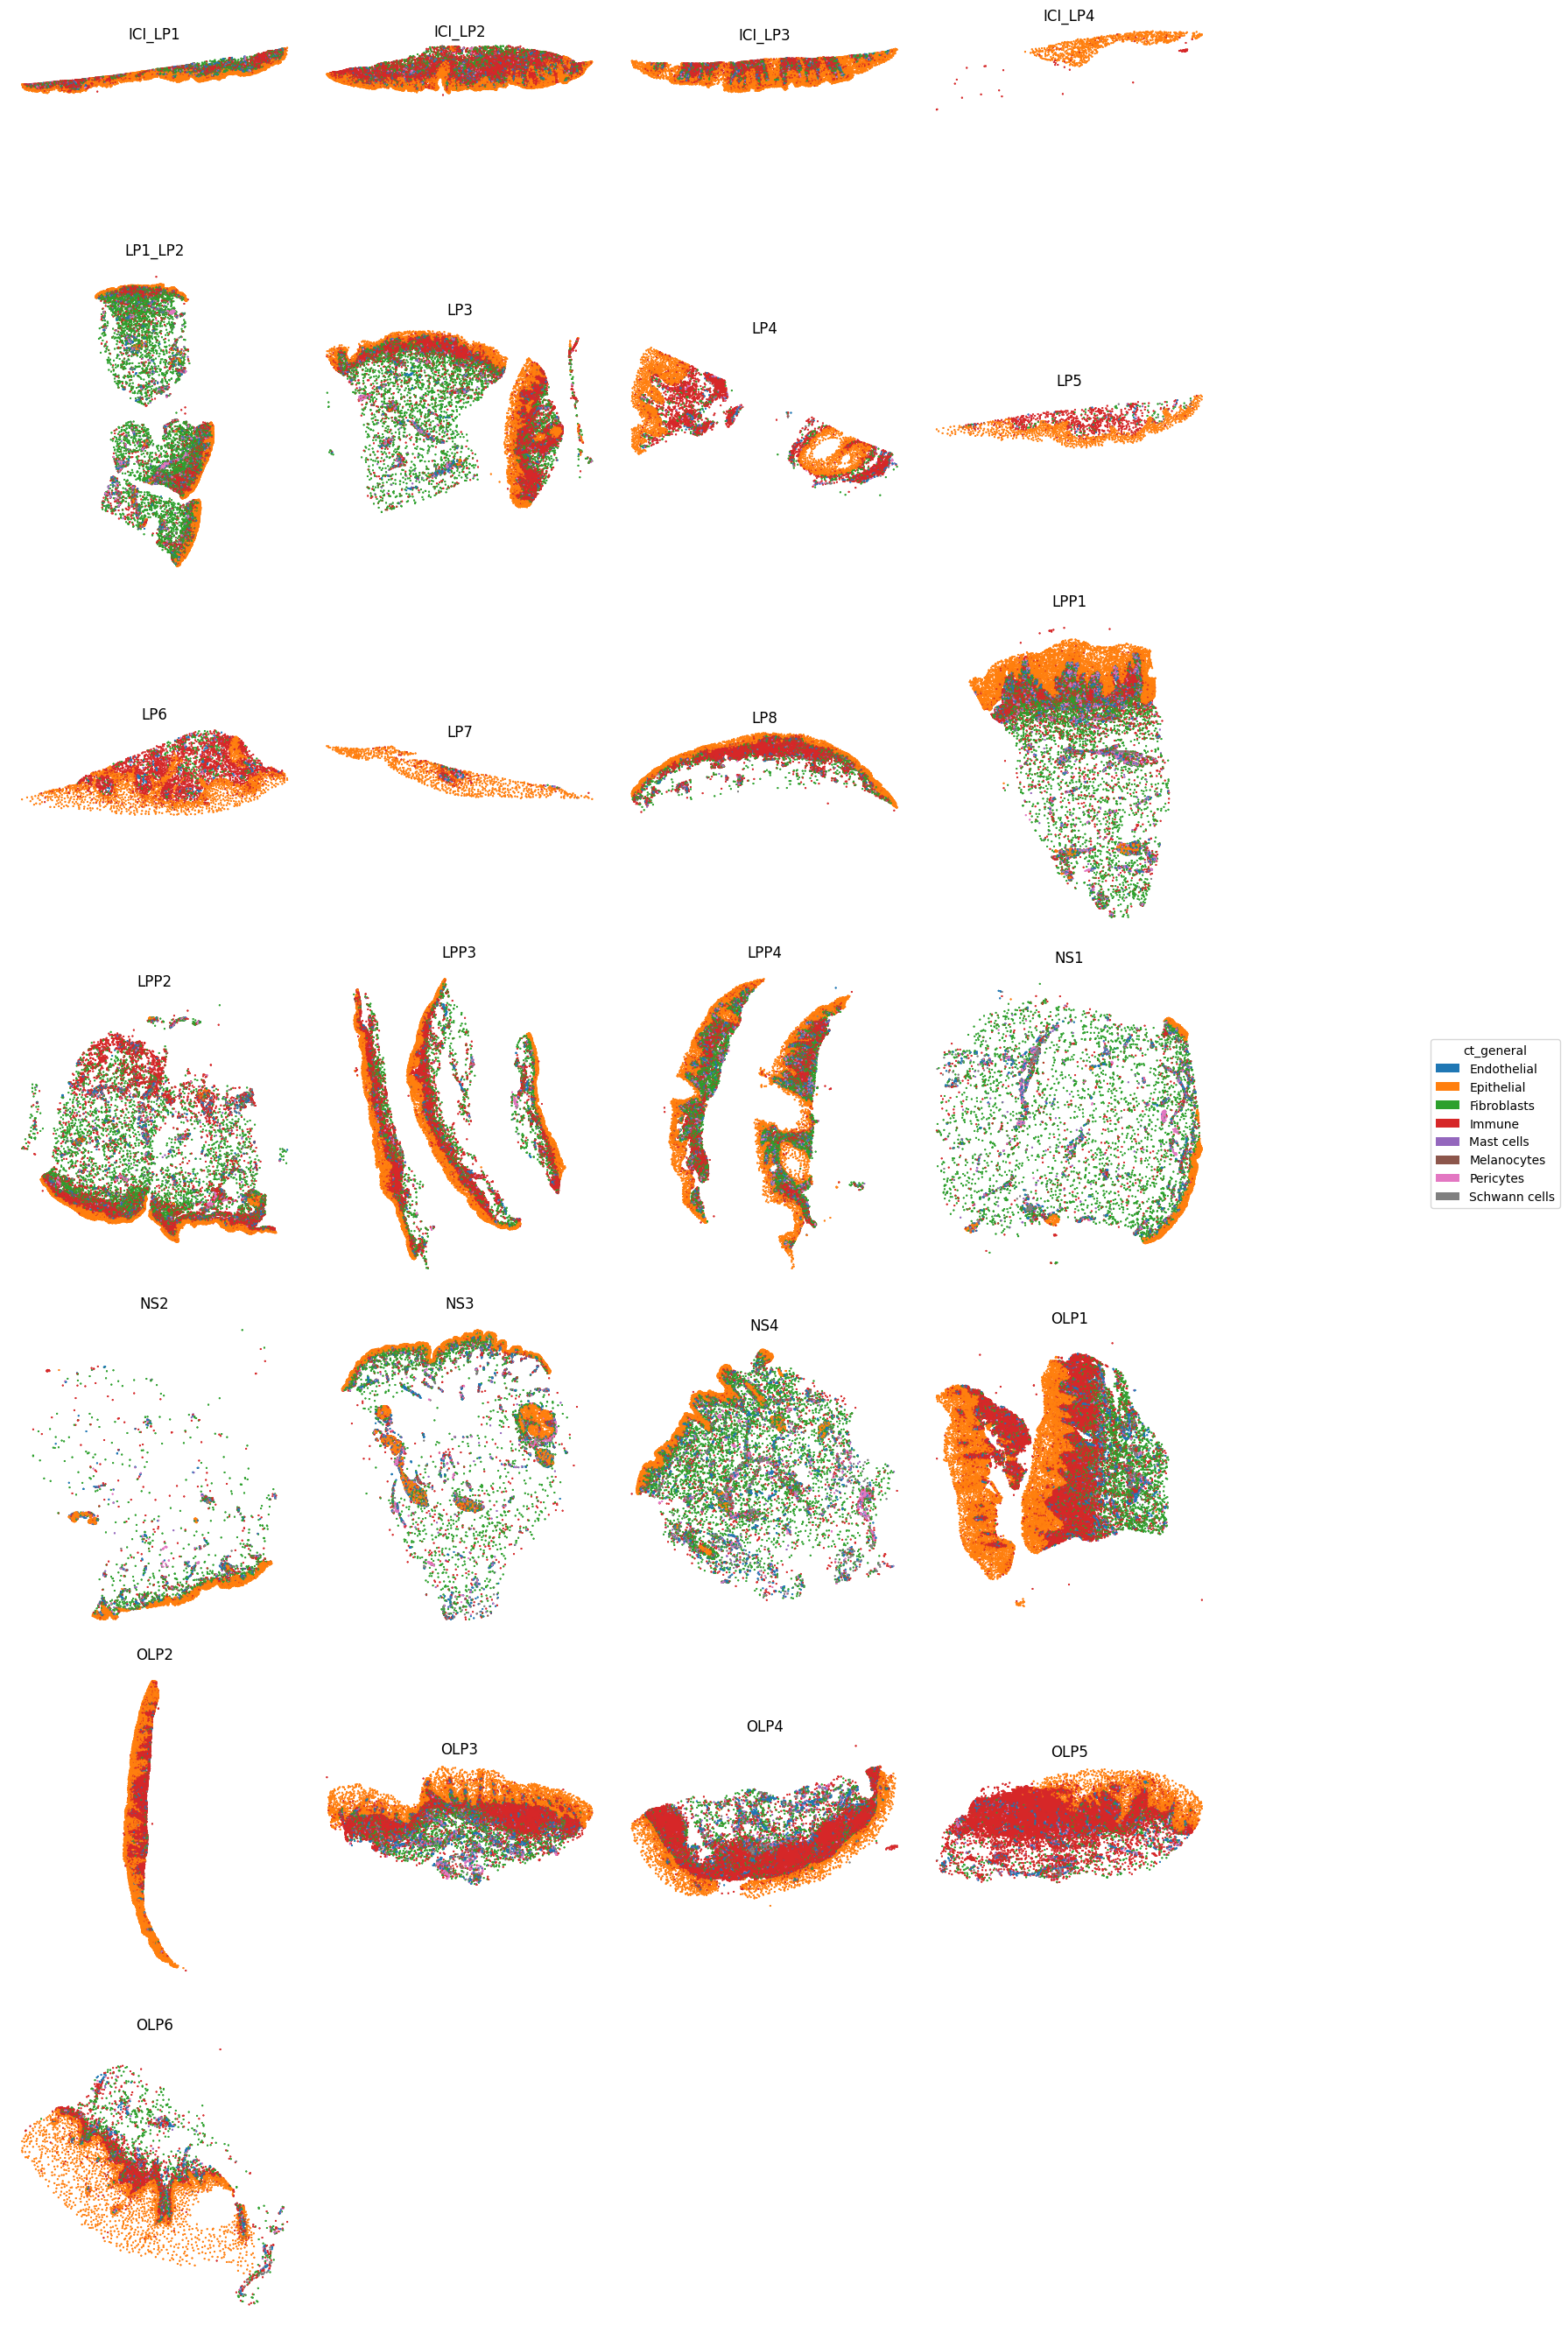

In [5]:
spatial_plot_cell_types_layered(adata, 'ct_general', n_cols=4)

/Users/burkelawlor/Repos/hci-xenium/.venv/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/Users/burkelawlor/Repos/hci-xenium/.venv/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/Users/burkelawlor/Repos/hci-xenium/.venv/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/Users/burkelawlor/Repos/hci-xenium/.venv/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/Users/burkelawlor/Repos/hci-xenium/.venv/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning

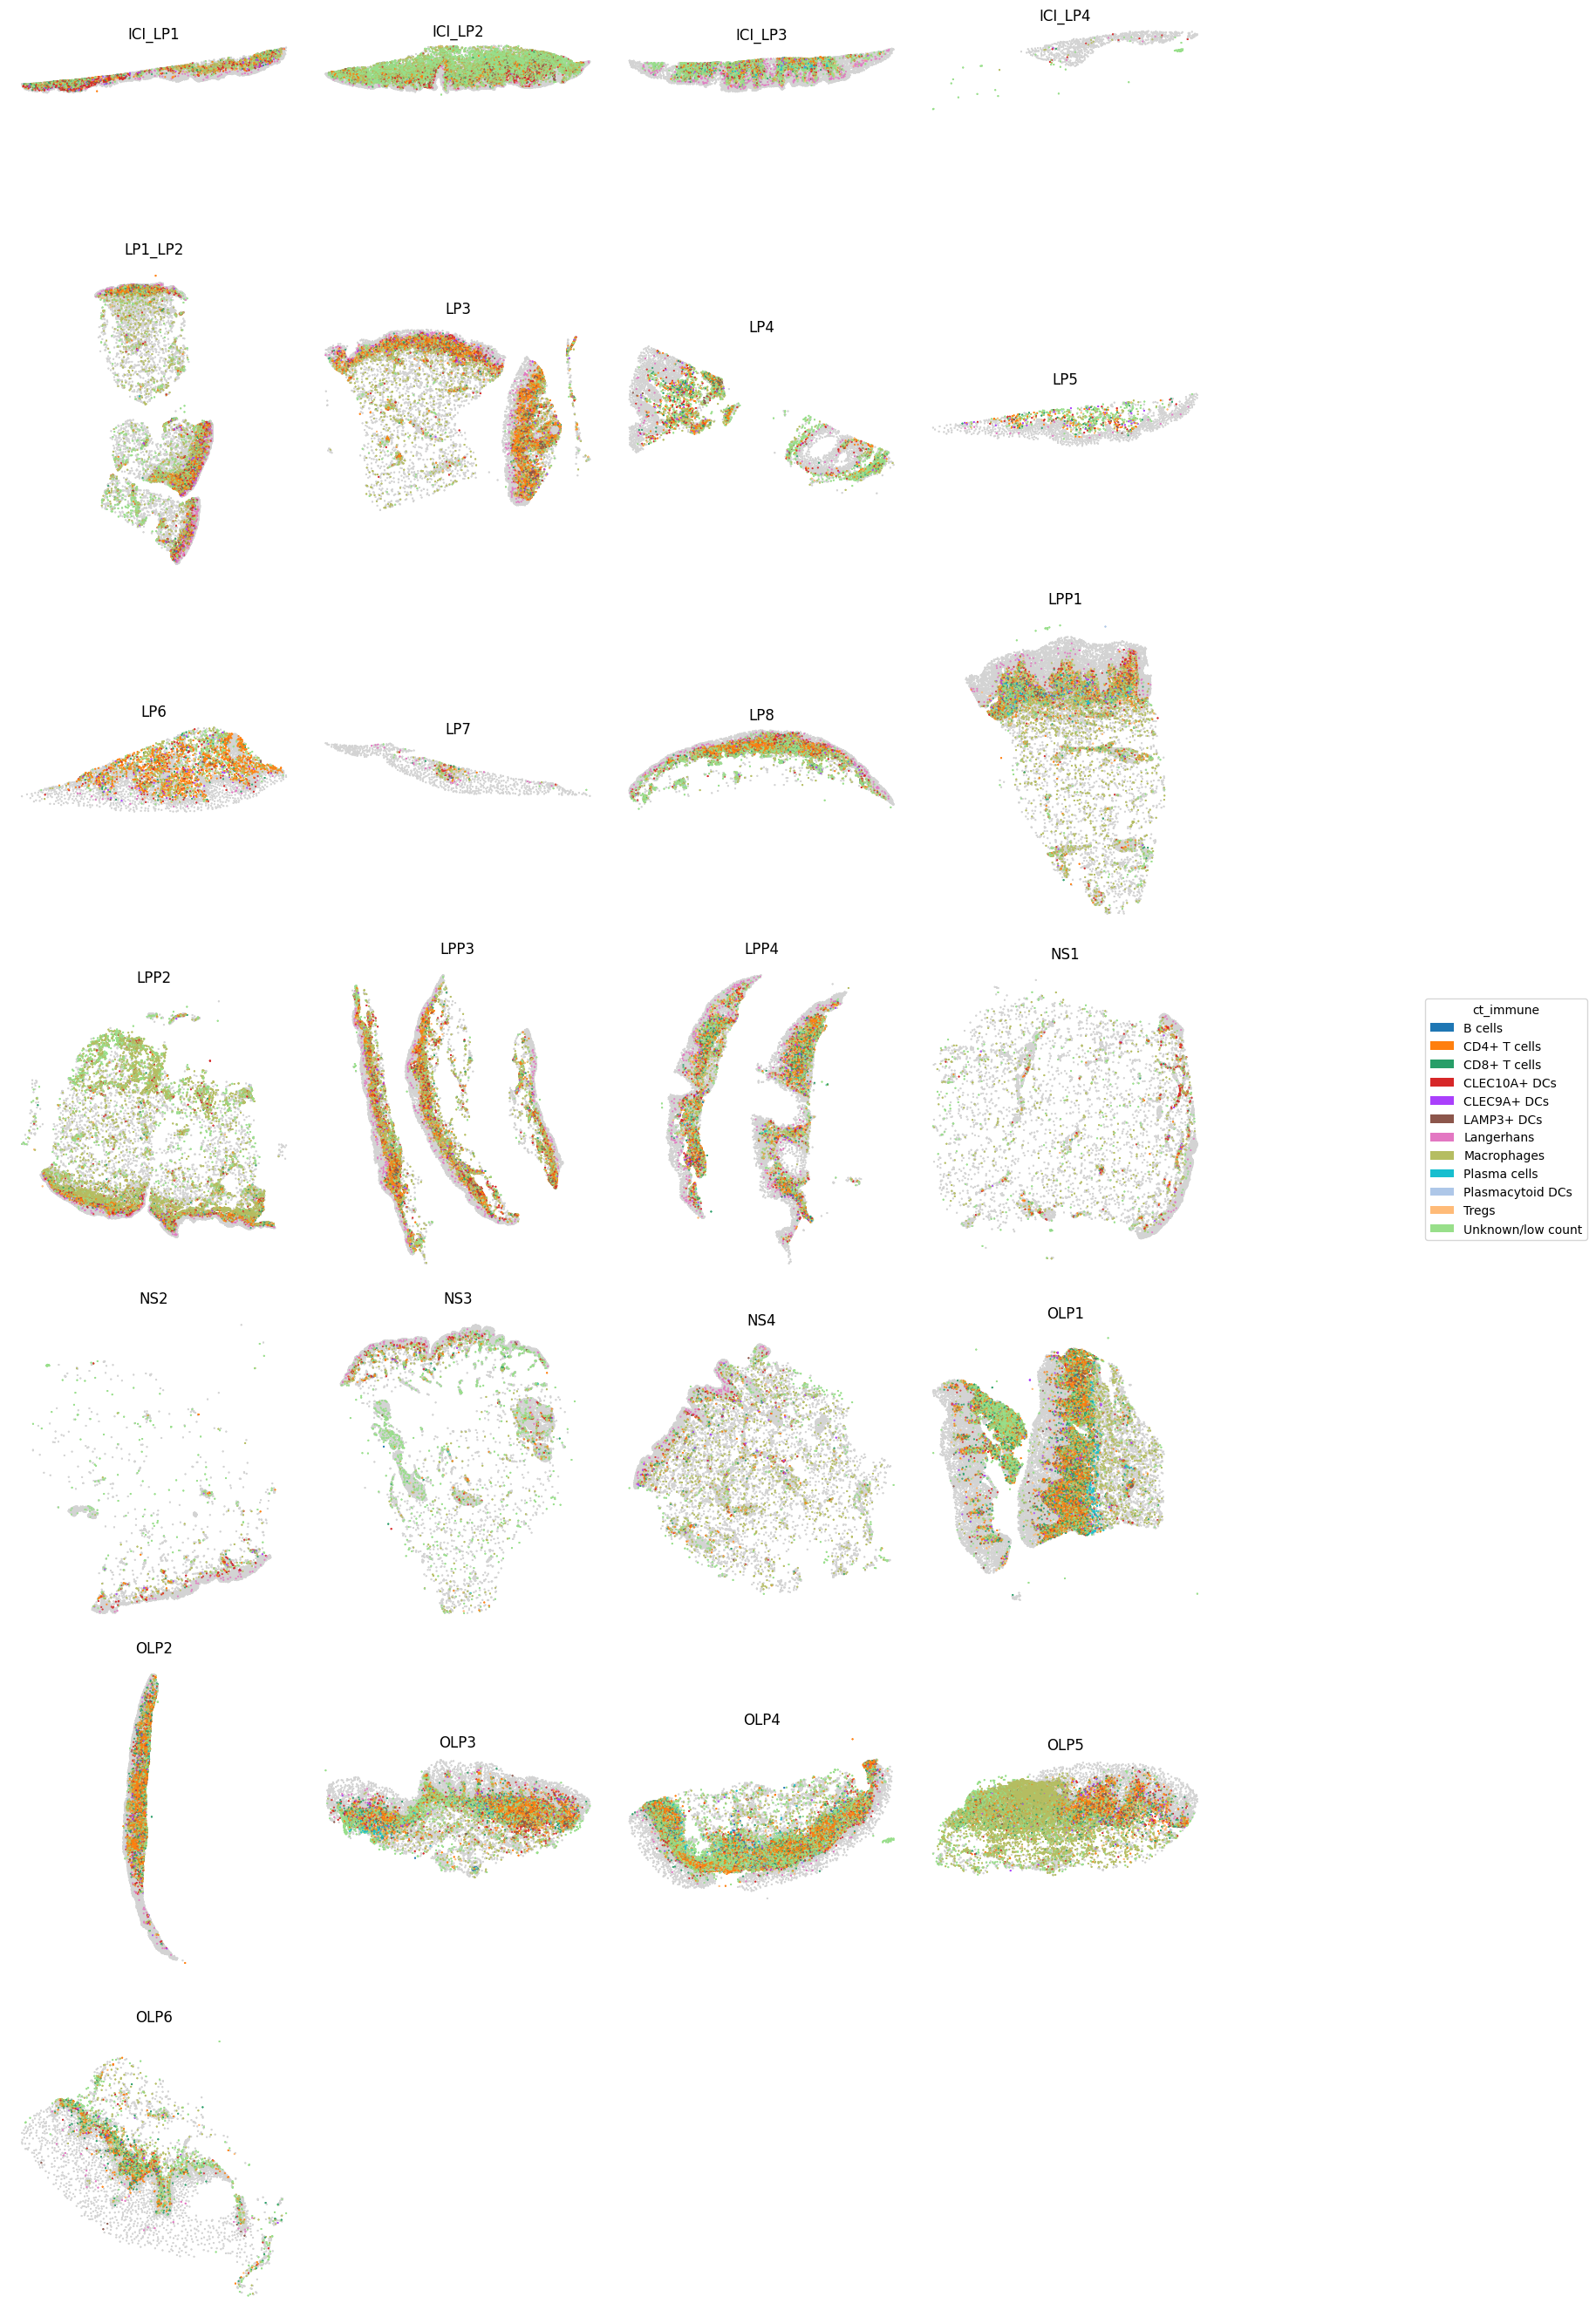

In [6]:
spatial_plot_cell_types_layered(adata, 'ct_immune', n_cols=4)

# Spatial plots of immune compartment

LP1
INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                


/Users/burkelawlor/Repos/hci-xenium/.venv/lib/python3.12/site-packages/spatialdata_plot/pl/utils.py:1123: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)


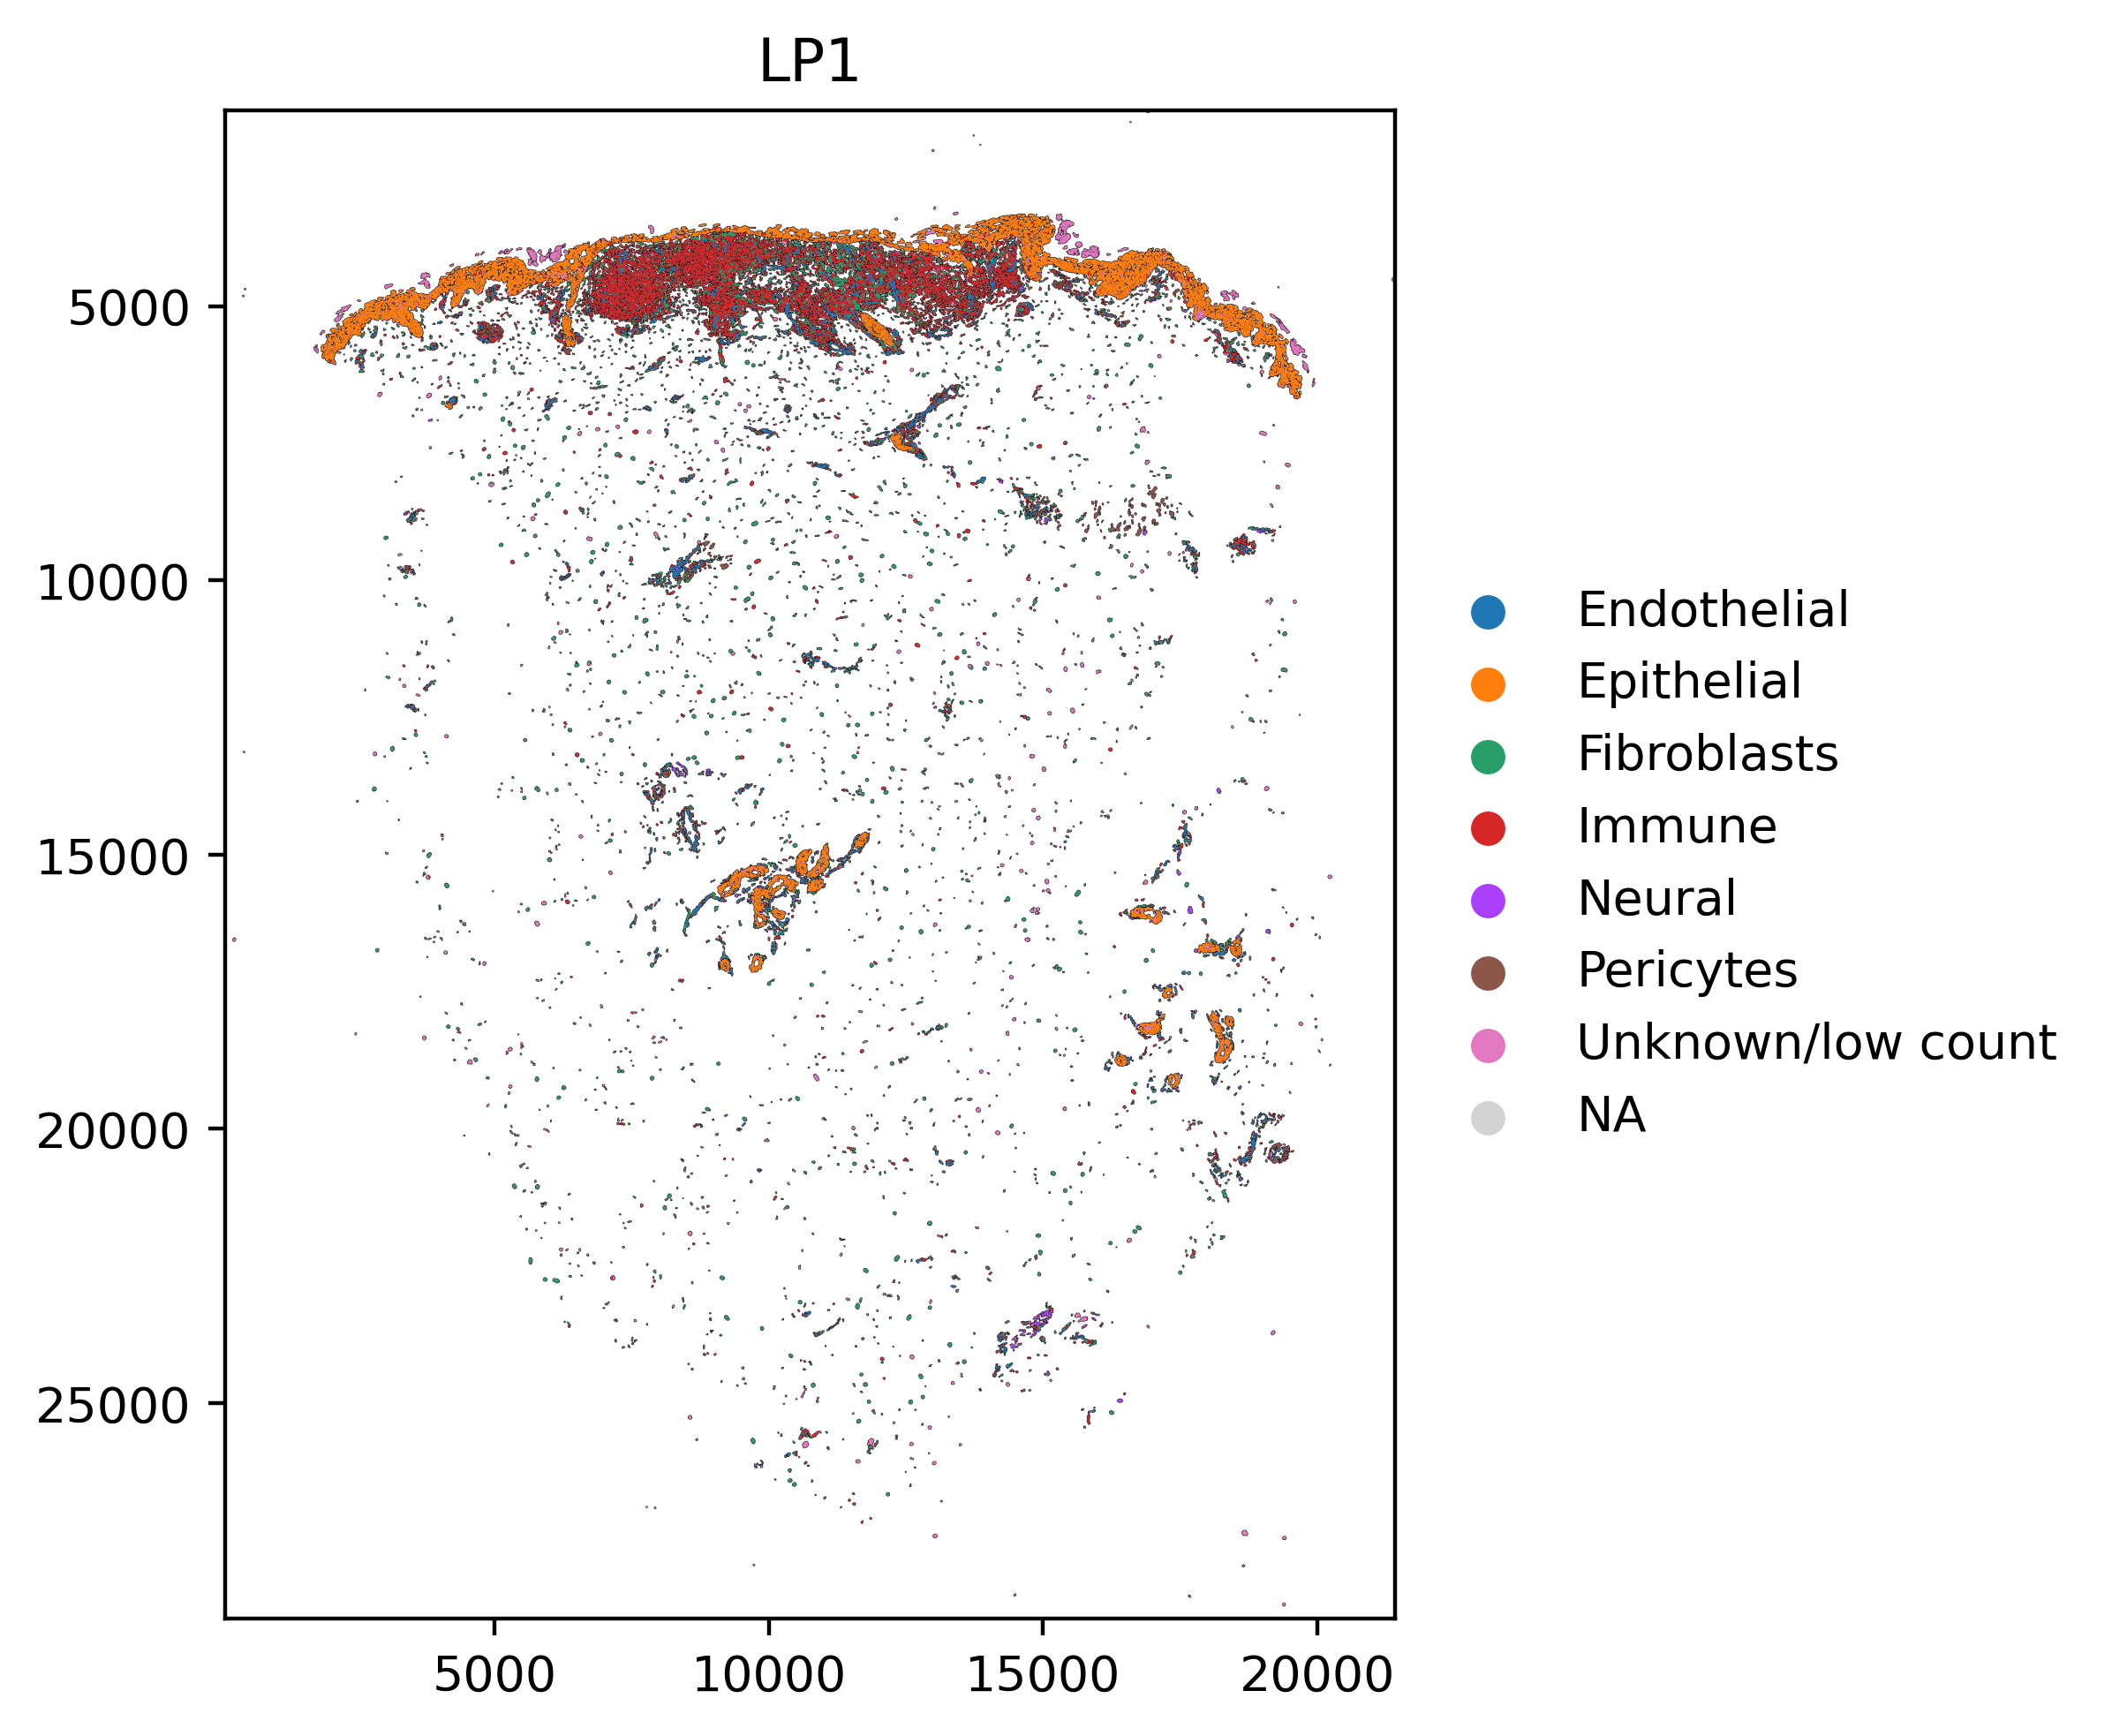

In [ ]:
color = 'ct_general_2'
groups = None

for sample, sdata in sdata_dict.items():
    print(sample)

    sdata.pl.render_shapes(
        "cell_boundaries",
        color=color,
        groups=groups,
        table_name="table_boundaries",
        fill_alpha=1,
        outline_alpha=1.0,
        outline_width=0.5,
    ).pl.show(title=sample, dpi=400)

    break

LP1


/Users/burkelawlor/Repos/hci-xenium/.venv/lib/python3.12/site-packages/spatialdata_plot/pl/utils.py:1123: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)


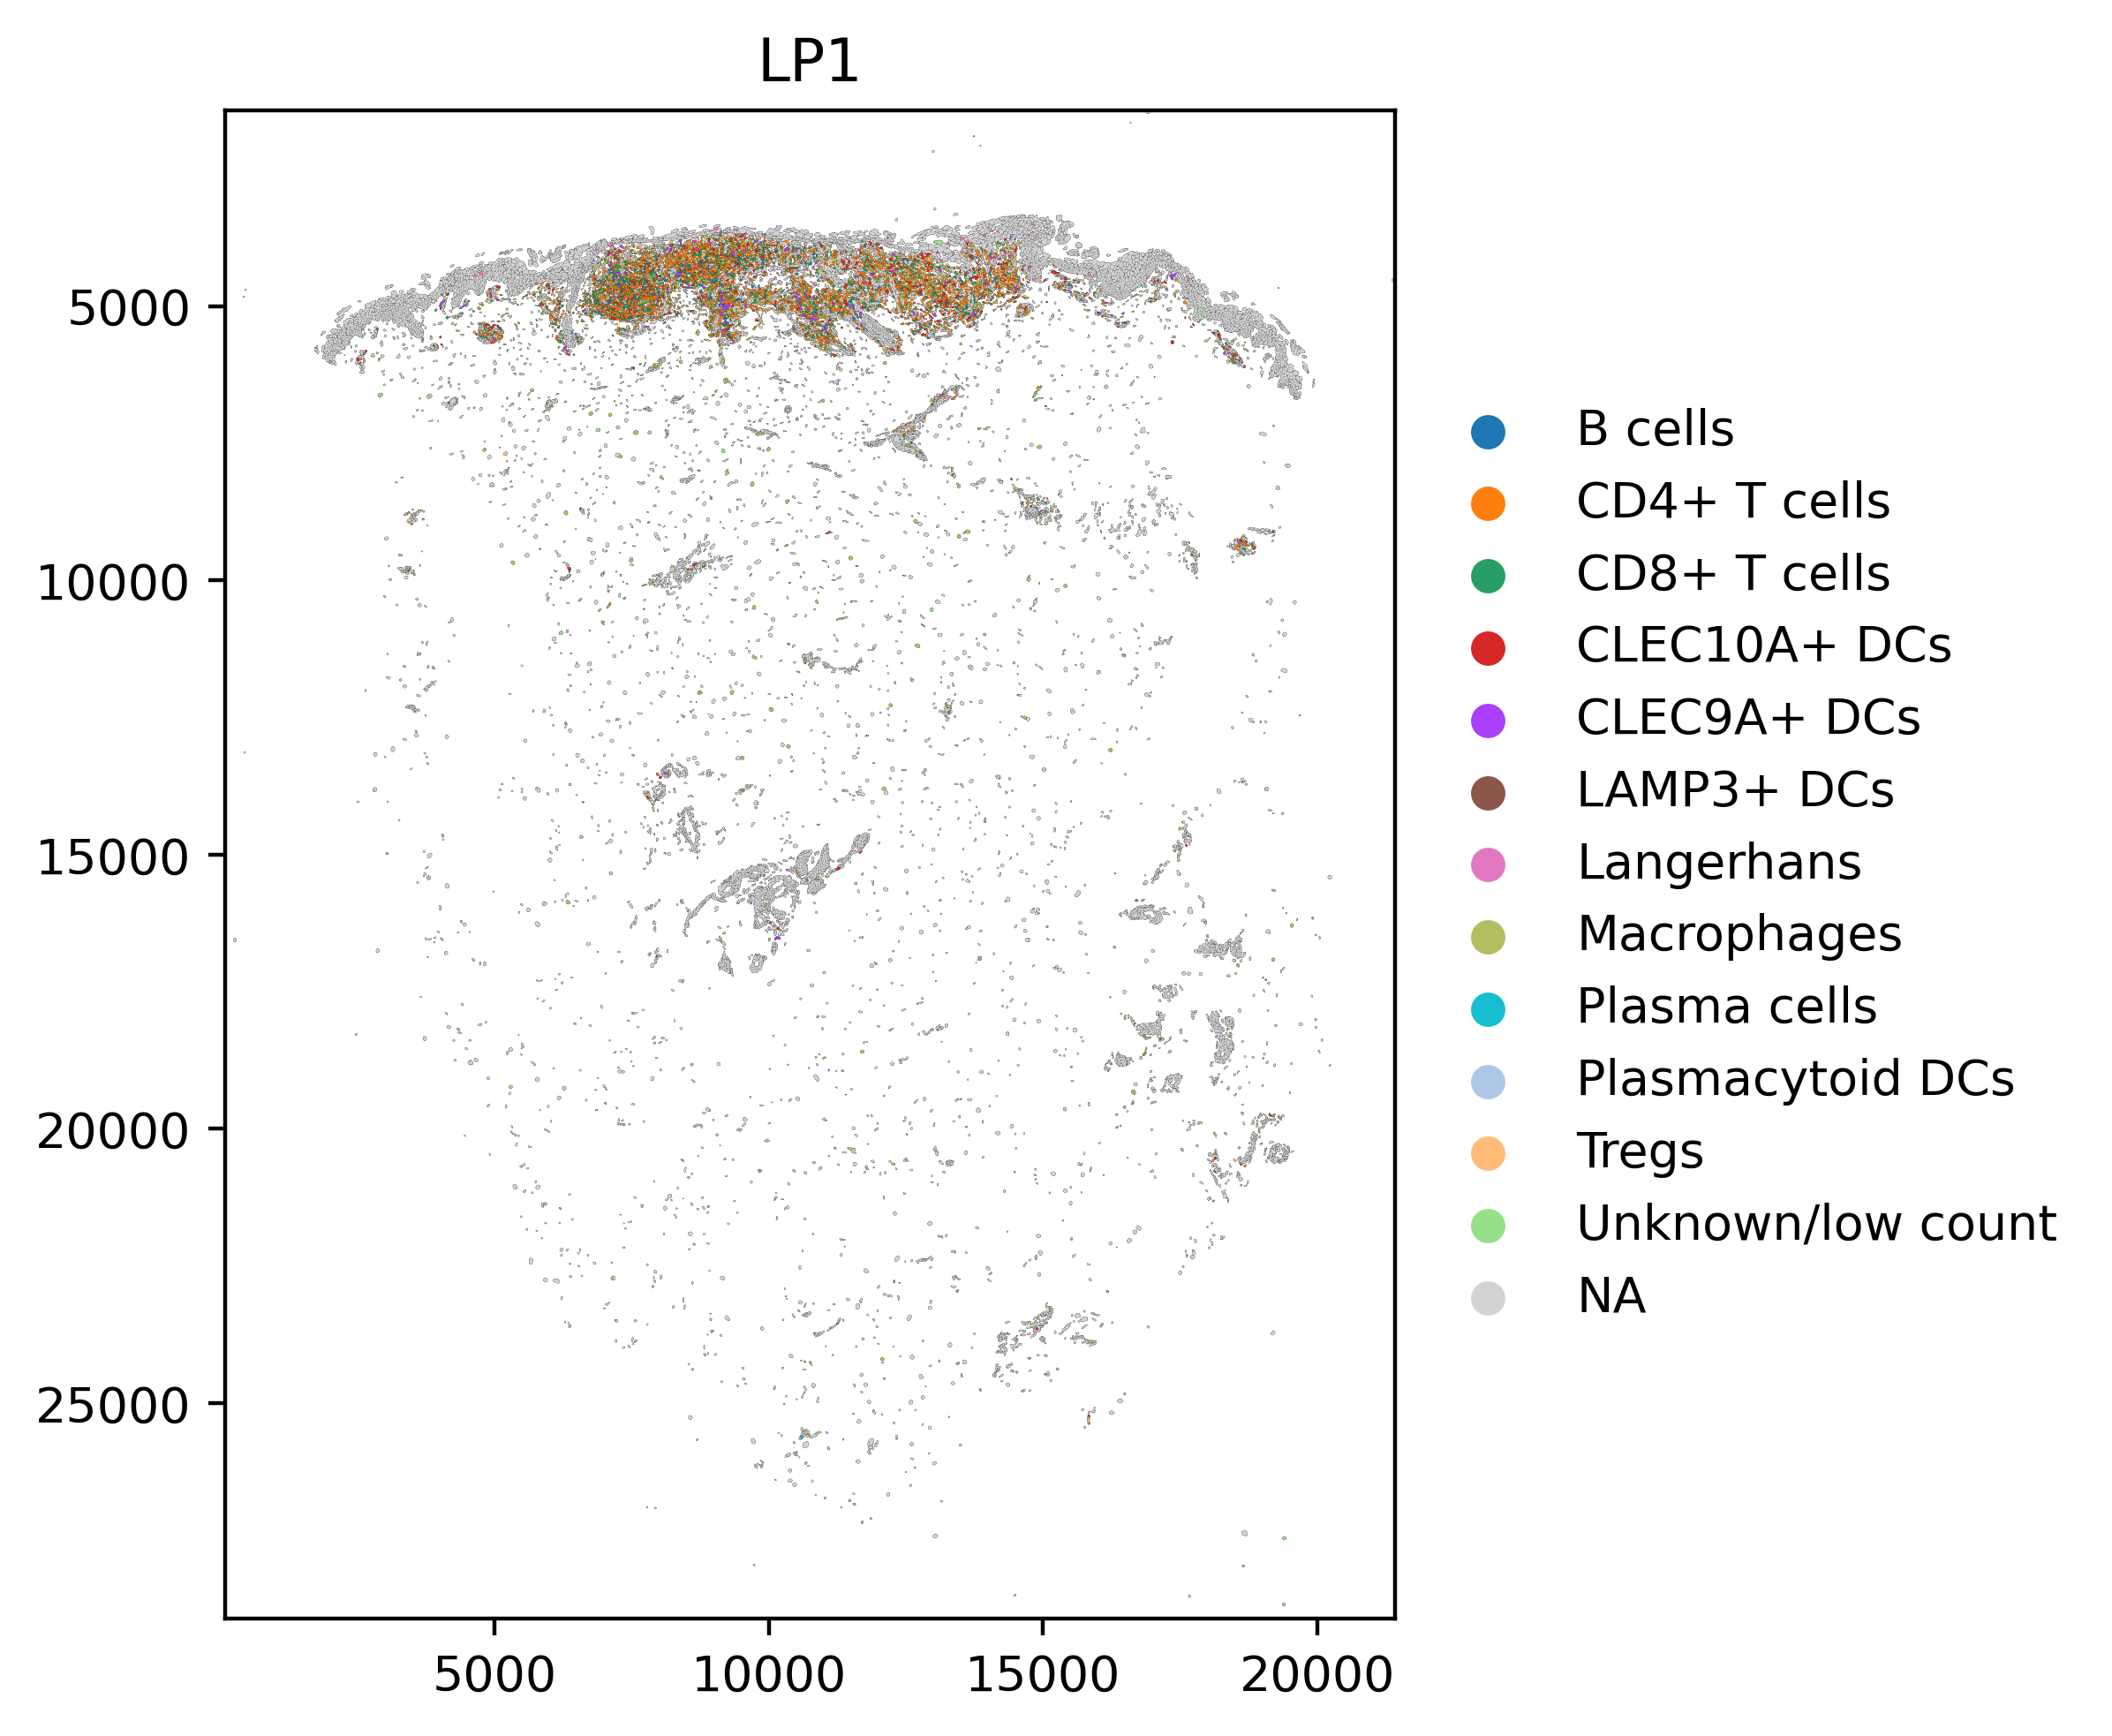

In [105]:
color = 'ct_immune'
# groups = ['CD8+ T cells', 'Tregs', 'Macrophages']
groups = None

for sample, sdata in sdata_dict.items():
    print(sample)

    sdata.pl.render_shapes(
        "cell_boundaries",
        color=color,
        groups=groups,
        na_color='lightgray',
        table_name="table_boundaries",
        fill_alpha=1,
        outline_alpha=1.0,
        outline_width=0.1,
        method='matplotlib'
    ).pl.show(title=sample, dpi=400)

    break

LP1


/opt/homebrew/Cellar/python@3.12/3.12.12_1/Frameworks/Python.framework/Versions/3.12/lib/python3.12/functools.py:912: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/burkelawlor/Repos/hci-xenium/.venv/lib/python3.12/site-packages/spatialdata_plot/pl/utils.py:1123: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)


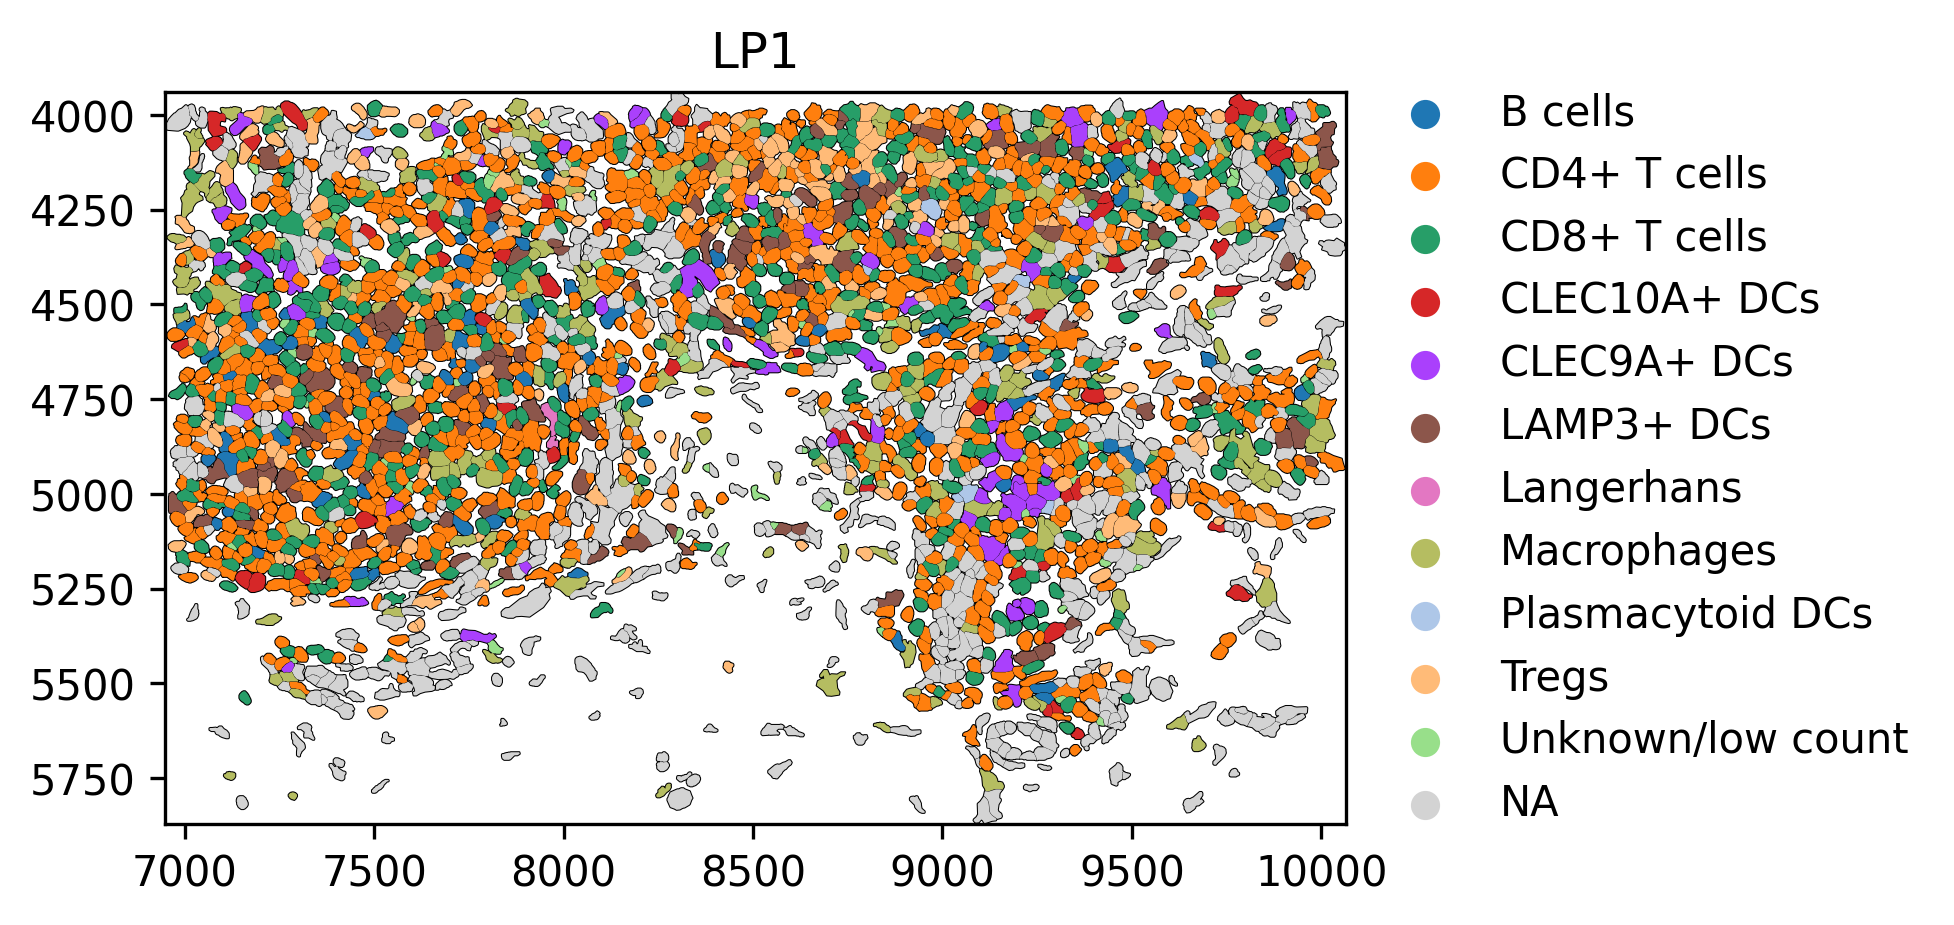

In [108]:
sample = 'LP1'
sdata = sdata_dict[sample]
print(sample)

color = 'ct_immune'
# groups = ['CD8+ T cells', 'Tregs', 'Macrophages']
groups = None


sdata_crop = sdata.query.bounding_box(
    axes=["x", "y"],
    min_coordinate=[7000, 4000],
    max_coordinate=[10000, 5800],
    target_coordinate_system="global",
)

sdata_crop.pl.render_shapes(
    "cell_boundaries",
    color=color,
    groups=groups,
    na_color='lightgray',
    table_name="table_boundaries",
    fill_alpha=1,
    outline_alpha=1.0,
    outline_width=0.5,
    method='matplotlib'
).pl.show(title=sample, dpi=300)

# CD94 co-expression

From Zach Hopkins via email 7/24/26: "which CD8+ t-cells have CD94 and which ones do not. It would be interesting to see these spatially (i.e. where in the infiltrate are these CD94+ cells, are they adjacent to apoptotic keratinocytes? Etc."

In [6]:
adata_lp

AnnData object with n_obs × n_vars = 488843 × 5001
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'centroidX', 'centroidY', 'cell_id_unique', 'sample_name', 'sample_set', 'batch', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'nucleus_ratio', 'n_genes', 'n_counts', 'rmc_ct_detailed', 'rmc_cell_type_general', 'leiden', 'leiden_1.0_general', 'ct_general', 'ct_endothelial', 'ct_epithelial', 'ct_immune', 'ct_detailed', 'ct_general_2'
    var: 'n_cells'
    uns: 'batch_colors', 'ct_detailed_colors', 'ct_endothelial_colors', 'ct_epithelial_colors', 'ct_general_2_colors', 'ct_general_colors', '